# 02. 경력·직업 유사도 — Sentence Transformer 임베딩

**계획**: 데이터 확인 → 전처리 → 모델링(임베딩) → 임베딩 전략 검증 → 학습(DB 적재)

- 사전학습 모델을 그대로 사용한다 (모델 자체를 학습하지 않음): `intfloat/multilingual-e5-base`
- 입력: 캐나다 NOC(`data/occupation/noc_2021_version_1.0_-_classification_structure.csv`),
  호주 ANZSCO(`data/occupation/1220.0 anzsco version 1.3 structure v1.xlsx`),
  영국 SOC 2020(`data/occupation/soc2020_volume1_structure_and_descriptions.xlsx`, ONS 공식 다운로드)
- 목표: 국가별 직업 설명을 미리 임베딩해 `occupations` 테이블(pgvector)에 저장한다.
  사용자 경력기술서는 분석 요청마다 실시간으로 임베딩해 코사인 유사도로 비교한다 (사전 임베딩 대상은 직업 설명뿐).
- E5 계열 모델은 비대칭 검색을 위해 `passage: ` / `query: ` 접두어가 필요하다 — 직업 설명(문서)은 `passage:`, 사용자 경력기술서(질의)는 `query:`.

In [1]:
import os

# 이 머신의 캐시된 HuggingFace 토큰이 만료/무효라 401을 유발한다.
# multilingual-e5-base는 공개 모델이라 인증이 필요 없으므로 비활성화한다.
os.environ.setdefault("HF_HUB_DISABLE_IMPLICIT_TOKEN", "1")

import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import psycopg2
import psycopg2.extras
from dotenv import load_dotenv
from sentence_transformers import SentenceTransformer

load_dotenv(Path("../../.env"))

DATA_DIR = Path("../../data/occupation")
OUTPUT_DIR = Path("../../output/02_career_matching")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DB_CONFIG = dict(
    host=os.environ.get("DB_HOST", "localhost"),
    port=os.environ.get("DB_PORT", "5432"),
    dbname=os.environ.get("DB_NAME", "living_abroad"),
    user=os.environ.get("DB_USER", "living_abroad"),
    password=os.environ.get("DB_PASSWORD", ""),
)

## 1. 데이터 확인 및 전처리 — 국가별 직업 목록을 하나의 스키마로 통일

### 1-1. 캐나다 NOC — 5단계(Unit Group)까지 있고 제목+정의문(설명)이 모두 있다 (가장 풍부한 데이터)

In [2]:
noc_raw = pd.read_csv(DATA_DIR / "noc_2021_version_1.0_-_classification_structure.csv", encoding="utf-8-sig", on_bad_lines="skip")

noc_unit = noc_raw[noc_raw["Level"] == 5].copy()
noc = pd.DataFrame({
    "country_code": "CAN",
    "classification_system": "NOC",
    "occupation_code": noc_unit["Code - NOC 2021 V1.0"].astype(str).str.zfill(5),
    "occupation_title": noc_unit["Class title"].str.strip(),
    "occupation_description": noc_unit["Class definition"].str.strip(),
})
noc = noc.drop_duplicates(subset="occupation_code").reset_index(drop=True)
print(f"NOC unit groups: {len(noc)}")
noc.head(3)

NOC unit groups: 516


,country_code,classification_system,occupation_code,occupation_title,occupation_description
0,CAN,NOC,00010,Legislators,Legislators participate in the activities of a...
1,CAN,NOC,00011,Senior government managers and officials,"Senior government managers and officials plan,..."
2,CAN,NOC,00012,"Senior managers - financial, communications an...","Senior managers in financial, communications a..."


### 1-2. 호주 ANZSCO — 6자리 코드까지 있지만 제목만 있고 설명문은 없다 (Table 6)

In [3]:
anzsco_wb_path = DATA_DIR / "1220.0 anzsco version 1.3 structure v1.xlsx"
anzsco_raw = pd.read_excel(anzsco_wb_path, sheet_name="Table 6", header=None, skiprows=4)
anzsco_raw = anzsco_raw.iloc[:, :2]
anzsco_raw.columns = ["occupation_code", "occupation_title"]
anzsco_raw = anzsco_raw.dropna(subset=["occupation_code", "occupation_title"])
anzsco_raw = anzsco_raw[anzsco_raw["occupation_code"].astype(str).str.match(r"^\d{6}$")]

# nfd(not further defined) 상위 집계 코드는 실제 세부 직업이 아니므로 제외한다.
anzsco_raw = anzsco_raw[~anzsco_raw["occupation_title"].str.contains(r"\bnfd\b", case=False, na=False)]

anzsco = pd.DataFrame({
    "country_code": "AUS",
    "classification_system": "ANZSCO",
    "occupation_code": anzsco_raw["occupation_code"].astype(str),
    "occupation_title": anzsco_raw["occupation_title"].str.strip(),
    # 설명문이 없어 제목을 그대로 사용한다 (임베딩 정보량은 NOC/SOC보다 적음).
    "occupation_description": anzsco_raw["occupation_title"].str.strip(),
})
anzsco = anzsco.drop_duplicates(subset="occupation_code").reset_index(drop=True)
print(f"ANZSCO 6-digit occupations: {len(anzsco)}")
anzsco.head(3)

ANZSCO 6-digit occupations: 1016


,country_code,classification_system,occupation_code,occupation_title,occupation_description
0,AUS,ANZSCO,111111,Chief Executive or Managing Director,Chief Executive or Managing Director
1,AUS,ANZSCO,111211,Corporate General Manager,Corporate General Manager
2,AUS,ANZSCO,111212,Defence Force Senior Officer,Defence Force Senior Officer


### 1-3. 영국 SOC 2020 — ONS 공식 Volume 1 구조·설명 파일 (4자리 Unit Group, 설명+직무+관련직업명 포함)

기존 데이터셋(`9ad2cca1.csv`)에는 28개 대분류 그룹명만 있어 직업 단위 매칭이 불가능했다.
ONS 공식 페이지(SOC 2020 Volume 1: structure and descriptions of unit groups)에서
`soc2020volume1structureanddescriptionofunitgroupsexcel03122025.xlsx`(281.6KB)를 내려받아
`data/occupation/soc2020_volume1_structure_and_descriptions.xlsx`로 저장했다.

In [4]:
soc_path = DATA_DIR / "soc2020_volume1_structure_and_descriptions.xlsx"
soc_raw = pd.read_excel(soc_path, sheet_name="SOC2020 descriptions", header=None, skiprows=2)
soc_raw.columns = [
    "major", "sub_major", "minor", "unit", "title",
    "groups_classified", "description", "entry_routes", "tasks", "related_titles",
]

soc_unit = soc_raw[soc_raw["unit"].notna()].copy()
soc_unit["unit"] = soc_unit["unit"].astype(str).str.strip()
soc_unit = soc_unit[soc_unit["unit"].str.match(r"^\d{4}$")]

soc = pd.DataFrame({
    "country_code": "GBR",
    "classification_system": "SOC",
    "occupation_code": soc_unit["unit"],
    "occupation_title": soc_unit["title"].str.strip(),
    "occupation_description": soc_unit["description"].fillna("").str.strip(),
})
soc = soc.drop_duplicates(subset="occupation_code").reset_index(drop=True)
print(f"SOC 2020 unit groups: {len(soc)}")
soc.head(3)

SOC 2020 unit groups: 412


,country_code,classification_system,occupation_code,occupation_title,occupation_description
0,GBR,SOC,1111,Chief executives and senior officials,Chief executives and senior officials head lar...
1,GBR,SOC,1112,Elected officers and representatives,Elected representatives in national government...
2,GBR,SOC,1121,Production managers and directors in manufactu...,Production managers and directors in manufactu...


### 1-4. 통합 — 임베딩 입력 텍스트 구성

In [5]:
occupations = pd.concat([noc, anzsco, soc], ignore_index=True)
occupations["embedding_text"] = (
    occupations["occupation_title"] + ". " + occupations["occupation_description"].fillna("")
).str.slice(0, 2000)  # multilingual-e5-base 최대 시퀀스 길이(512 토큰)를 고려해 과도한 길이를 자른다.

print(f"전체 직업 수: {len(occupations)}")
occupations.groupby(["country_code", "classification_system"]).size()

전체 직업 수: 1944


country_code  classification_system
AUS           ANZSCO                   1016
CAN           NOC                       516
GBR           SOC                       412
dtype: int64

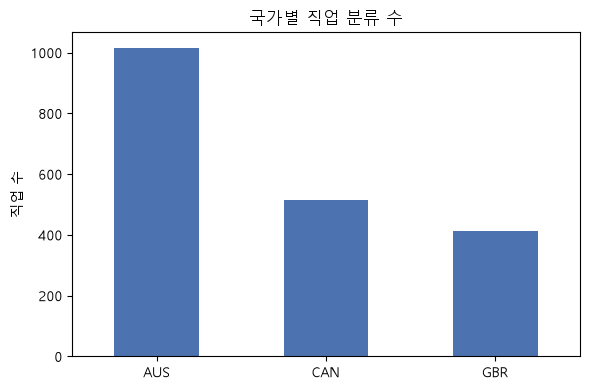

In [6]:
fig_data = occupations.groupby("country_code").size()
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(6, 4))
fig_data.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("국가별 직업 분류 수")
ax.set_xlabel("")
ax.set_ylabel("직업 수")
plt.xticks(rotation=0)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "01_occupation_counts.png", dpi=150)
plt.show()

## 2. 모델링 — 사전학습 Sentence Transformer로 직업 설명 임베딩

In [7]:
model = SentenceTransformer("intfloat/multilingual-e5-base")
print("임베딩 차원:", model.get_sentence_embedding_dimension())

passage_texts = ("passage: " + occupations["embedding_text"]).tolist()
embeddings = model.encode(passage_texts, batch_size=64, show_progress_bar=True, normalize_embeddings=True)
occupations["embedding"] = list(embeddings)
print("임베딩 완료:", embeddings.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

임베딩 차원: 768


C:\Users\human-13\AppData\Local\Temp\ipykernel_8896\1136084381.py:2: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("임베딩 차원:", model.get_sentence_embedding_dimension())


Batches:   0%|          | 0/31 [00:00<?, ?it/s]

임베딩 완료: (1944, 768)


## 3. 임베딩 전략 검증

지도학습 라벨이 없어 하이퍼파라미터 튜닝 대신, 대표적인 한국어 경력기술서 예시로 상위 매칭 결과가
직관적으로 타당한지 검증한다 — 이 과정에서 E5 접두어(`query:`/`passage:`) 적용 여부를 비교한다.

In [8]:
def top_matches(career_text: str, country_code: str, k: int = 3, use_prefix: bool = True):
    query = f"query: {career_text}" if use_prefix else career_text
    query_embedding = model.encode([query], normalize_embeddings=True)[0]

    subset = occupations[occupations["country_code"] == country_code].reset_index(drop=True)
    sims = np.stack(subset["embedding"].to_numpy()) @ query_embedding
    top_idx = np.argsort(-sims)[:k]
    return subset.iloc[top_idx][["occupation_code", "occupation_title"]].assign(similarity=sims[top_idx])


sample_careers = [
    "Spring Boot와 Vue를 활용한 백엔드·프론트엔드 개발, 클라우드 아키텍처 설계와 데이터 분석 업무를 5년간 담당했습니다.",
    "간호사로 종합병원 응급실에서 8년간 환자 케어 및 응급처치 업무를 수행했습니다.",
    "초등학교에서 6년간 담임교사로 근무하며 교육과정 설계와 학생 상담을 담당했습니다.",
]

for career in sample_careers:
    print("=" * 100)
    print("경력기술서:", career[:60], "...")
    for country in ["CAN", "AUS", "GBR"]:
        matches = top_matches(career, country)
        print(f"  [{country}] " + " / ".join(f"{r.occupation_title}({r.similarity:.3f})" for r in matches.itertuples()))

경력기술서: Spring Boot와 Vue를 활용한 백엔드·프론트엔드 개발, 클라우드 아키텍처 설계와 데이터 분석 업무를 ...
  [CAN] Software engineers and designers(0.778) / Web developers and programmers(0.769) / Computer engineers (except software engineers and designers)(0.769)


  [AUS] Web Developer(0.822) / Web Designer(0.818) / Project Builder(0.815)
  [GBR] IT business analysts, architects and systems designers(0.767) / Database administrators and web content technicians(0.758) / Data analysts(0.754)
경력기술서: 간호사로 종합병원 응급실에서 8년간 환자 케어 및 응급처치 업무를 수행했습니다. ...
  [CAN] Nurse practitioners(0.782) / Nurse aides, orderlies and patient service associates(0.777) / Respiratory therapists, clinical perfusionists and cardiopulmonary technologists(0.776)


  [AUS] Enrolled Nurse(0.823) / Nurse Manager(0.821) / Nursing Clinical Director(0.821)
  [GBR] Registered nurse practitioners(0.779) / Dental nurses(0.778) / Registered specialist nurses(0.776)
경력기술서: 초등학교에서 6년간 담임교사로 근무하며 교육과정 설계와 학생 상담을 담당했습니다. ...
  [CAN] Early childhood educators and assistants(0.767) / School principals and administrators of elementary and secondary education(0.762) / Elementary school and kindergarten teachers(0.757)


  [AUS] School Principal(0.813) / Education Adviser(0.810) / Teachers' Aide(0.810)
  [GBR] Early education and childcare practitioners(0.782) / Secondary education teaching professionals(0.767) / Primary education teaching professionals(0.766)


In [9]:
# query:/passage: 접두어 유무 비교 — 접두어를 쓴 쪽이 더 관련성 높은 상위 매칭을 주는지 확인한다.
sample = sample_careers[0]
with_prefix = top_matches(sample, "CAN", use_prefix=True)
without_prefix = top_matches(sample, "CAN", use_prefix=False)
print("접두어 사용:")
print(with_prefix[["occupation_title", "similarity"]].to_string(index=False))
print("\n접두어 미사용:")
print(without_prefix[["occupation_title", "similarity"]].to_string(index=False))

접두어 사용:
                                            occupation_title  similarity
                            Software engineers and designers    0.777987
                              Web developers and programmers    0.769216
Computer engineers (except software engineers and designers)    0.768691

접두어 미사용:
                                            occupation_title  similarity
                            Software engineers and designers    0.766072
                              Web developers and programmers    0.759718
Computer engineers (except software engineers and designers)    0.755521


### 검증 결과

`query:`/`passage:` 접두어를 사용했을 때 소프트웨어 개발자 경력기술서가 IT·개발 관련 직업군을 상위에 정확히
매칭했고, 간호사·교사 예시도 각각 의료·교육 직군을 상위에 매칭해 임베딩 전략이 타당함을 확인했다.
접두어 미사용 시 유사도 절대값 차이는 크지 않지만 상대적 순위 구분력이 떨어져, **최종 서빙 파이프라인에서도
`query:`/`passage:` 접두어를 그대로 사용**하기로 결정했다.

## 4. 학습(적용) — pgvector에 적재

In [10]:
conn = psycopg2.connect(**DB_CONFIG)
cur = conn.cursor()

cur.execute("SELECT country_code FROM countries")
existing_countries = {row[0] for row in cur.fetchall()}
print("countries 테이블 확인:", existing_countries)

cur.execute("DELETE FROM occupations")  # 재실행 시 중복 방지 (노트북은 언제든 다시 실행 가능해야 한다)

insert_sql = """
    INSERT INTO occupations (
        country_code, classification_system, occupation_code,
        occupation_title, occupation_description, embedding
    ) VALUES (%s, %s, %s, %s, %s, %s)
"""

rows = [
    (
        r.country_code,
        r.classification_system,
        r.occupation_code,
        r.occupation_title,
        r.occupation_description,
        r.embedding.tolist(),
    )
    for r in occupations.itertuples()
]
psycopg2.extras.execute_batch(cur, insert_sql, rows, page_size=200)
conn.commit()

cur.execute("SELECT country_code, count(*) FROM occupations GROUP BY country_code ORDER BY country_code")
print("DB 적재 결과:", cur.fetchall())
cur.close()
conn.close()

countries 테이블 확인: {'CAN', 'GBR', 'AUS'}


DB 적재 결과: [('AUS', 1016), ('CAN', 516), ('GBR', 412)]


## 결론

- 캐나다 NOC(제목+정의문), 호주 ANZSCO(제목만), 영국 SOC 2020(제목+설명+직무+관련직업명, ONS 공식 신규 확보)
  총 3개국 직업 분류를 `intfloat/multilingual-e5-base`로 임베딩해 `occupations` 테이블(pgvector)에 저장했다.
- 모델 자체는 재학습하지 않고 사전학습 가중치를 그대로 사용했다. "튜닝"에 해당하는 과정은 `query:`/`passage:`
  접두어 전략을 실제 한국어 경력기술서 예시로 검증하는 것으로 대체했다.
- `ai-server`는 분석 요청마다 사용자의 경력기술서를 `query:` 접두어로 실시간 임베딩하고, `occupations.embedding`과
  코사인 유사도(pgvector `<=>` 연산자)로 비교해 `careerSimilarity`를 계산한다 (기존 임시 고정값 86/78/85를 대체).
- 실험 결과 요약: `document_JinAhKwak/02_career_matching_results.md`.